In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"
df = pd.read_csv(url)

# Conversione della colonna date in datetime
df['date'] = pd.to_datetime(df['date'])

In [3]:
print(f"Dataset shape (rows, cols): {df.shape}")
df.head()

Dataset shape (rows, cols): (429435, 67)


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


## Struttura del dataset
Il metodo `info()` fornisce una panoramica strutturale del dataset, mostrando:
- Numero totale di righe e colonne
- Nomi delle variabili
- Tipo di dato di ciascuna colonna
- Numero di valori non nulli per colonna
Si osserva che:
- Il dataset contiene sia variabili numeriche sia variabili categoriche.
- Sono presenti valori mancanti in diverse colonne.
- La colonna `date` è inizialmente memorizzata come oggetto (stringa) e dovrà essere convertita in formato datetime per effettuare analisi temporali corrette. ##

In [ ]:
df.info()

In [5]:
df.describe()

,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,429435,4.118040e+05,4.101590e+05,4.089290e+05,4.118040e+05,410608.000000,409378.000000,411804.000000,410159.000000,408929.000000,...,243817.000000,161741.000000,290689.000000,390299.000000,319127.000000,4.294350e+05,1.341100e+04,13411.000000,13411.000000,13411.000000
mean,2022-04-21 01:06:25.463691008,7.365292e+06,8.017360e+03,8.041026e+03,8.125957e+04,71.852139,72.060828,112096.199420,122.357073,122.713852,...,33.097758,50.649390,3.106895,73.702098,0.722178,1.520336e+08,5.604765e+04,9.766431,10.925353,1772.666404
min,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.190000,0.100000,53.280000,0.390000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2936.450000
25%,2021-03-05 00:00:00,6.280750e+03,0.000000e+00,0.000000e+00,4.300000e+01,0.000000,0.000000,1916.100000,0.000000,0.000000,...,22.600000,20.860000,1.300000,69.500000,0.600000,5.237980e+05,1.765000e+02,2.060000,-1.500000,116.875000
50%,2022-04-20 00:00:00,6.365300e+04,0.000000e+00,1.200000e+01,7.990000e+02,0.000000,0.000000,29145.480000,0.000000,2.790000,...,33.100000,49.540000,2.500000,75.050000,0.740000,6.336393e+06,6.815200e+03,8.130000,5.660000,1270.800000
75%,2023-06-08 00:00:00,7.582720e+05,0.000000e+00,3.132900e+02,9.574000e+03,0.000000,3.140000,156770.190000,0.000000,56.250000,...,41.500000,82.500000,4.210000,79.460000,0.830000,3.296952e+07,3.912804e+04,15.160000,15.575000,2883.025000
max,2024-08-14 00:00:00,7.758668e+08,4.423623e+07,6.319461e+06,7.057132e+06,103719.000000,14817.000000,763598.600000,241758.230000,34536.890000,...,78.100000,100.000000,13.800000,86.750000,0.960000,7.975105e+09,1.349776e+06,78.080000,378.220000,10293.520000
std,NaN,4.477582e+07,2.296649e+05,8.661611e+04,4.411901e+05,1368.322990,513.636565,162240.412405,1508.778585,559.701663,...,13.853952,31.905236,2.549168,7.387914,0.149237,6.975408e+08,1.568691e+05,12.040658,24.560706,1991.892770


In [6]:
print("Colonne del dataset:")
print(df.columns.tolist())

Colonne del dataset:
['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_

In [7]:
# Analisi delle location: alcune sono paesi, altre sono aggregati continentali
print("\nLocation uniche:", df['location'].nunique())
print("\nEsempi di location:")
print(df['location'].unique()[:20])


Location uniche: 255

Esempi di location:
['Afghanistan' 'Africa' 'Albania' 'Algeria' 'American Samoa' 'Andorra'
 'Angola' 'Anguilla' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Asia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain'
 'Bangladesh' 'Barbados']


In [8]:
# Verifica dei continenti
print("\nContinenti presenti:")
print(df['continent'].unique())
print(f"\nValori nulli in 'continent': {df['continent'].isna().sum()}")


Continenti presenti:
['Asia' nan 'Europe' 'Africa' 'Oceania' 'North America' 'South America']

Valori nulli in 'continent': 26525


In [9]:
# ATTENZIONE: Alcune location sono aggregati (es. "World", "Europe", "Asia")
# Verifichiamo quali location NON hanno un continente associato
aggregati = df[df['continent'].isna()]['location'].unique()
print("\nLocation senza continente (probabilmente aggregati):")
print(aggregati)


Location senza continente (probabilmente aggregati):
['Africa' 'Asia' 'Europe' 'European Union (27)' 'High-income countries'
 'Low-income countries' 'Lower-middle-income countries' 'North America'
 'Oceania' 'South America' 'Upper-middle-income countries' 'World']


In [10]:
# Verifica valori nulli nelle colonne chiave
colonne_chiave = ['total_cases', 'new_cases', 'total_deaths', 'icu_patients', 'hosp_patients']
print("\nValori nulli nelle colonne chiave:")
print(df[colonne_chiave].isnull().sum())


Valori nulli nelle colonne chiave:
total_cases       17631
new_cases         19276
total_deaths      17631
icu_patients     390319
hosp_patients    388779
dtype: int64


In [13]:

# Filtiamo solo i paesi veri (escludendo aggregati continentali)
df_countries = df[df['continent'].notna()].copy()

# Per ogni paese, prendiamo il massimo valore di total_cases (ultimo dato disponibile)
casi_per_paese = df_countries.groupby(['continent', 'location'])['total_cases'].max().reset_index()

# Sommiamo per continente
casi_continente = casi_per_paese.groupby('continent')['total_cases'].sum().sort_values(ascending=False)

print("Casi totali per continente (dall'inizio della pandemia):")
print(casi_continente)
print(f"\nTotale mondiale: {casi_continente.sum():,.0f}")

Casi totali per continente (dall'inizio della pandemia):
continent
Asia             301532347.0
Europe           252916868.0
North America    124492666.0
South America     68809418.0
Oceania           15003352.0
Africa            13145540.0
Name: total_cases, dtype: float64

Totale mondiale: 775,900,191


In [14]:
# Calcolo della percentuale rispetto al totale mondiale
totale_mondiale = casi_continente.sum()
percentuali = (casi_continente / totale_mondiale * 100).round(2)

# Creiamo un dataframe riepilogativo
riepilogo = pd.DataFrame({
    'Casi Totali': casi_continente,
    'Percentuale (%)': percentuali
})

print("\nRiepilogo casi per continente:")
print(riepilogo)


Riepilogo casi per continente:
               Casi Totali  Percentuale (%)
continent                                  
Asia           301532347.0            38.86
Europe         252916868.0            32.60
North America  124492666.0            16.04
South America   68809418.0             8.87
Oceania         15003352.0             1.93
Africa          13145540.0             1.69


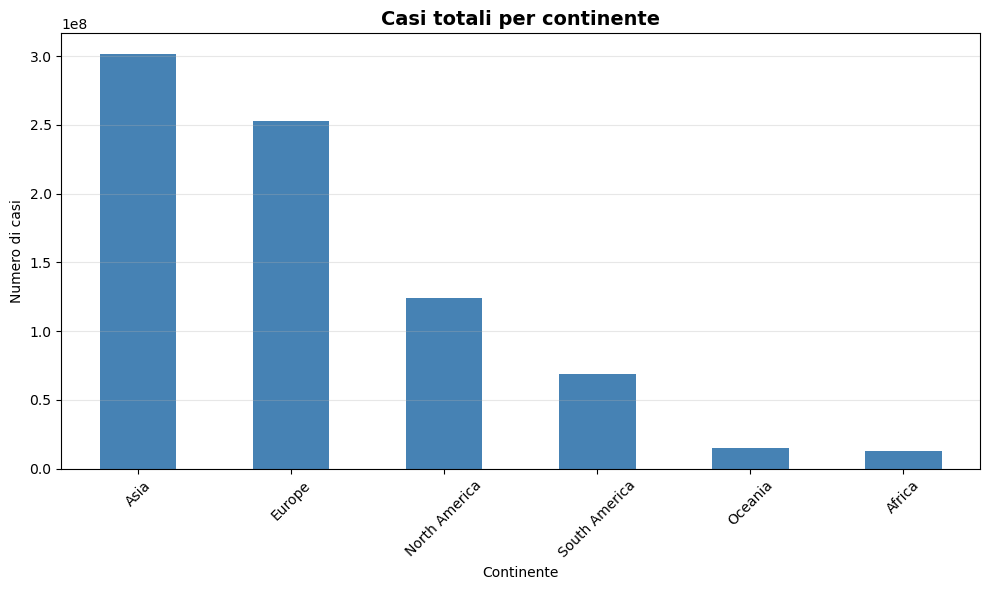

In [31]:
# Visualizzazione grafica - solo grafico a barre
plt.figure(figsize=(10, 6))
casi_continente.plot(kind='bar', color='steelblue')
plt.title('Casi totali per continente', fontsize=14, fontweight='bold')
plt.xlabel('Continente')
plt.ylabel('Numero di casi')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3️ Analisi Italia - Anno 2022

In [17]:
# Filtro per Italia e anno 2022
italy_2022 = df[(df['location'] == 'Italy') & (df['date'].dt.year == 2022)].copy()

# CORREZIONE: Filtriamo i giorni che NON hanno misurazioni (NaN), non gli zeri
# Gli zeri sono valori reali (giorni senza nuovi casi), i NaN sono giorni senza rilevamento
italy_2022 = italy_2022[italy_2022['new_cases'].notna()]

print(f"Numero di osservazioni per l'Italia nel 2022: {len(italy_2022)}")
print(f"\nPrime righe:")
italy_2022[['date', 'total_cases', 'new_cases']].head(10)

Numero di osservazioni per l'Italia nel 2022: 365

Prime righe:


,date,total_cases,new_cases
186002,2022-01-01,5622431.0,0.0
186003,2022-01-02,6267035.0,644604.0
186004,2022-01-03,6267035.0,0.0
186005,2022-01-04,6267035.0,0.0
186006,2022-01-05,6267035.0,0.0
186007,2022-01-06,6267035.0,0.0
186008,2022-01-07,6267035.0,0.0
186009,2022-01-08,6267035.0,0.0
186010,2022-01-09,7281297.0,1014262.0
186011,2022-01-10,7281297.0,0.0


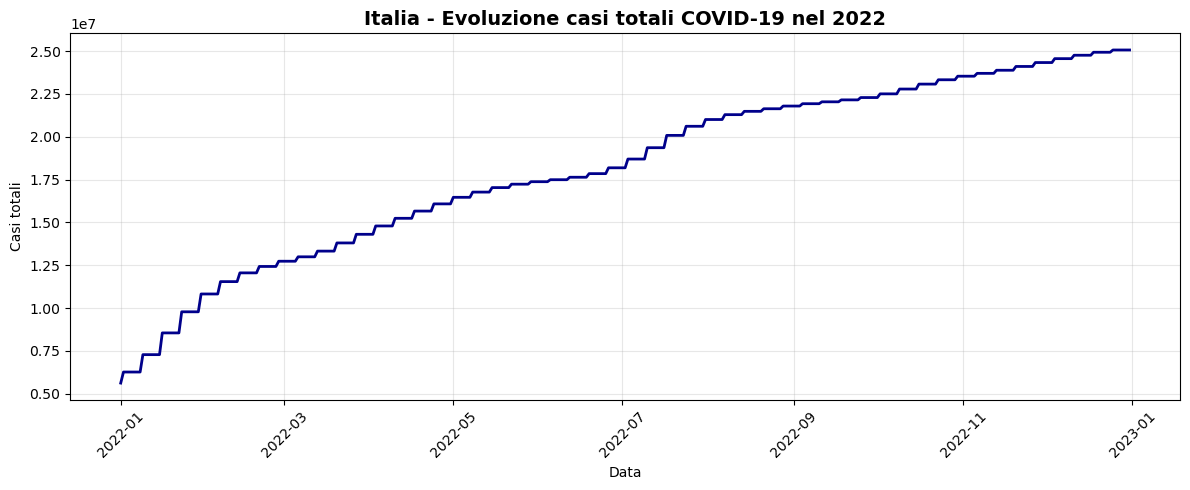

In [33]:
# Grafico evoluzione casi totali
plt.figure(figsize=(12, 5))
plt.plot(italy_2022['date'], italy_2022['total_cases'], linewidth=2, color='darkblue')
plt.title('Italia - Evoluzione casi totali COVID-19 nel 2022', fontsize=14, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Casi totali')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

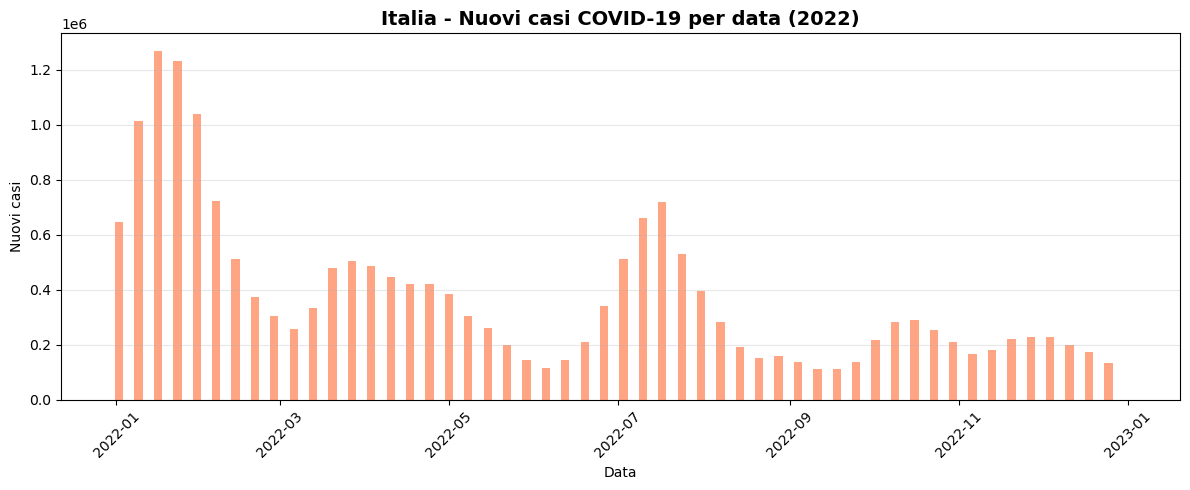

In [20]:
# Grafico nuovi casi giornalieri
plt.figure(figsize=(12, 5))
plt.bar(italy_2022['date'], italy_2022['new_cases'], width=3, color='coral', alpha=0.7)
plt.title('Italia - Nuovi casi COVID-19 per data (2022)', fontsize=14, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Nuovi casi')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4 Confronto tra le nazioni di Italia, Germania e Francia:

In [21]:
# Filtro per i tre paesi e il periodo richiesto
paesi = ['Italy', 'Germany', 'France']
icu_data = df[
    (df['location'].isin(paesi)) & 
    (df['date'] >= '2022-05-01') & 
    (df['date'] <= '2023-04-30')
].copy()

# Rimuoviamo i valori nulli per icu_patients
icu_data = icu_data[icu_data['icu_patients'].notna()]

print(f"Numero di osservazioni per paese:")
print(icu_data.groupby('location').size())

Numero di osservazioni per paese:
location
France     335
Germany    365
Italy      365
dtype: int64


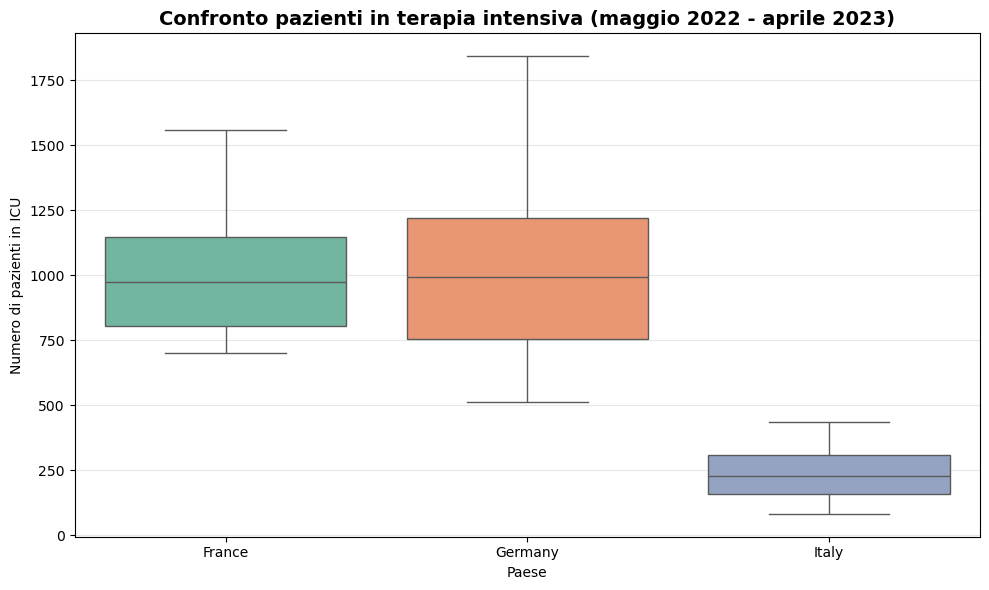


Statistiche descrittive per paese:
            mean    50%    min     max
location                              
France     998.4  972.0  699.0  1557.0
Germany   1022.4  994.0  512.0  1842.0
Italy      231.3  227.0   82.0   434.0


In [22]:
# Boxplot per confrontare i pazienti in terapia intensiva
plt.figure(figsize=(10, 6))
sns.boxplot(data=icu_data, x='location', y='icu_patients', palette='Set2')
plt.title('Confronto pazienti in terapia intensiva (maggio 2022 - aprile 2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Paese')
plt.ylabel('Numero di pazienti in ICU')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiche descrittive
print("\nStatistiche descrittive per paese:")
print(icu_data.groupby('location')['icu_patients'].describe()[['mean', '50%', 'min', 'max']].round(1))

### Commento sul grafico ICU

Il boxplot mostra che Germania e Francia hanno registrato un numero di pazienti in terapia intensiva significativamente superiore rispetto all’Italia nel periodo considerato. La Germania presenta inoltre una maggiore variabilità e valori massimi più elevati, mentre l’Italia mantiene livelli mediamente più contenuti.

In [23]:
# Filtro per i quattro paesi e anno 2021
paesi_hosp = ['Italy', 'Germany', 'France', 'Spain']
hosp_2021 = df[
    (df['location'].isin(paesi_hosp)) & 
    (df['date'].dt.year == 2021)
].copy()

print(f"Numero totale di osservazioni: {len(hosp_2021)}")
print(f"\nOsservazioni per paese:")
print(hosp_2021.groupby('location').size())

Numero totale di osservazioni: 1460

Osservazioni per paese:
location
France     365
Germany    365
Italy      365
Spain      365
dtype: int64


## 5️ Pazienti ospedalizzati (hosp_patients) - Anno 2021

In [24]:
# Verifica dei valori nulli per hosp_patients
print("Valori nulli per hosp_patients per paese:")
null_counts = hosp_2021.groupby('location')['hosp_patients'].apply(lambda x: x.isna().sum())
total_counts = hosp_2021.groupby('location').size()
null_summary = pd.DataFrame({
    'Valori nulli': null_counts,
    'Totale osservazioni': total_counts,
    'Percentuale nulli (%)': (null_counts / total_counts * 100).round(1)
})
print(null_summary)

Valori nulli per hosp_patients per paese:
          Valori nulli  Totale osservazioni  Percentuale nulli (%)
location                                                          
France               0                  365                    0.0
Germany            365                  365                  100.0
Italy                0                  365                    0.0
Spain                0                  365                    0.0


In [25]:
# Calcolo della somma dei pazienti ospedalizzati (escludendo i valori nulli)
sum_hosp = hosp_2021.groupby('location')['hosp_patients'].sum().sort_values(ascending=False)

print("\nSomma dei pazienti ospedalizzati nel 2021:")
print(sum_hosp.apply(lambda x: f"{x:,.0f}"))


Somma dei pazienti ospedalizzati nel 2021:
location
France     6,008,717
Italy      4,419,950
Spain      2,411,706
Germany            0
Name: hosp_patients, dtype: object


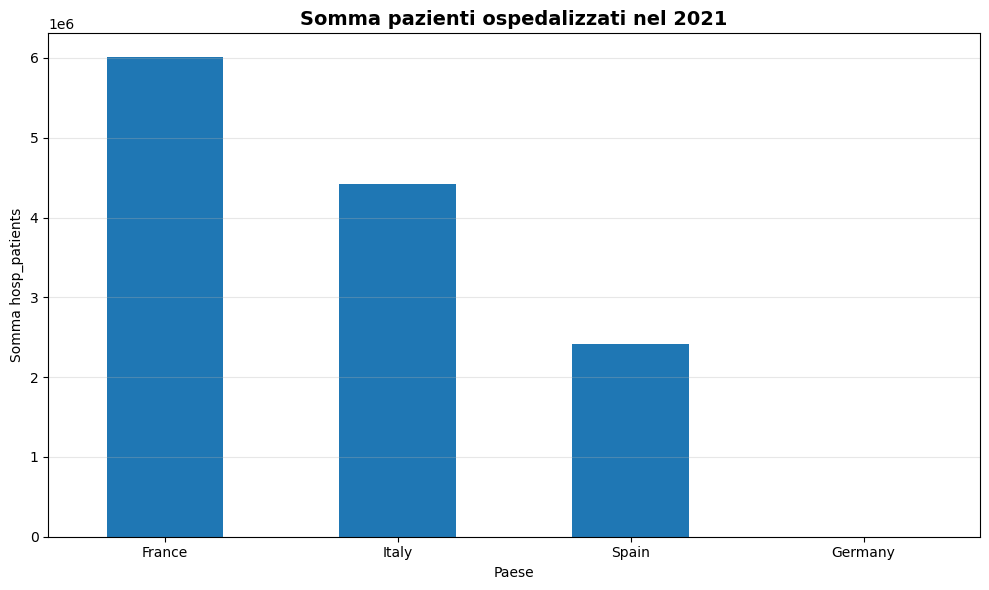

In [27]:
# Visualizzazione grafica
plt.figure(figsize=(10, 6))
sum_hosp.plot(kind='bar')
plt.title('Somma pazienti ospedalizzati nel 2021', fontsize=14, fontweight='bold')
plt.xlabel('Paese')
plt.ylabel('Somma hosp_patients')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Commento sulla gestione dei valori nulli

Dall'analisi dei valori nulli emerge che per la **Germania** nel 2021 la colonna `hosp_patients` presenta **esclusivamente valori mancanti** (100% di dati nulli). Questo indica che la Germania non ha fornito questi dati specifici per il 2021 al dataset Our World in Data.
Per gli altri tre paesi (Italia, Francia, Spagna) i dati sono **completi** (0% di valori nulli), quindi non è necessaria alcuna sostituzione o imputazione.
**Conclusione**: Nel caso della Germania, **non è possibile gestire i dati mancanti tramite sostituzione** poiché l'assenza è totale e sistematica. Qualsiasi metodo di imputazione (media, interpolazione, ecc.) sarebbe arbitrario e scientificamente scorretto. Per analisi comparative che richiedono questo dato, la Germania deve essere esclusa oppure si devono utilizzare fonti dati alternative.